In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numba import njit

In [2]:
# Global config
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

TRAIN_PATH = "train_ratings.csv"
VAL_PATH = "val_ratings.csv"
TEST_PATH = "test_ratings.csv"

In [3]:
# Load data
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())

Train shape: (800204, 4)
Val shape: (100002, 4)
Test shape: (100003, 4)


,user_id,movie_id,rating,timestamp
0,3650,1791,3,966459999
1,2857,2365,3,972507382
2,3789,1034,5,966021326
3,4682,648,3,965531092
4,5268,2791,5,961171110


In [4]:
# Basic checks
total_n = len(train_df) + len(val_df) + len(test_df)

print("Train proportion:", len(train_df) / total_n)
print("Val proportion:", len(val_df) / total_n)
print("Test proportion:", len(test_df) / total_n)

print("Train rating min/max:", train_df["rating"].min(), train_df["rating"].max())
print("Val rating min/max:", val_df["rating"].min(), val_df["rating"].max())
print("Test rating min/max:", test_df["rating"].min(), test_df["rating"].max())

required_cols = {"user_id", "movie_id", "rating"}
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"{name} file missing columns: {missing}")

Train proportion: 0.8000367923104071
Val proportion: 0.0999811039492746
Test proportion: 0.09998210374031827
Train rating min/max: 1 5
Val rating min/max: 1 5
Test rating min/max: 1 5


In [5]:
# Build mappings
all_user_ids = pd.Index(
    pd.concat([train_df["user_id"], val_df["user_id"], test_df["user_id"]]).unique()
)
all_movie_ids = pd.Index(
    pd.concat([train_df["movie_id"], val_df["movie_id"], test_df["movie_id"]]).unique()
)

user2idx = {uid: i for i, uid in enumerate(all_user_ids)}
movie2idx = {mid: i for i, mid in enumerate(all_movie_ids)}

idx2user = {i: uid for uid, i in user2idx.items()}
idx2movie = {i: mid for mid, i in movie2idx.items()}

n_users = len(user2idx)
n_items = len(movie2idx)

print("Number of users:", n_users)
print("Number of movies:", n_items)

Number of users: 6040
Number of movies: 3706


In [6]:
# Map ids to internal indices
def map_df(df):
    out = df.copy()
    out["u_idx"] = out["user_id"].map(user2idx)
    out["i_idx"] = out["movie_id"].map(movie2idx)
    return out

train_df = map_df(train_df)
val_df = map_df(val_df)
test_df = map_df(test_df)

display(train_df.head())

,user_id,movie_id,rating,timestamp,u_idx,i_idx
0,3650,1791,3,966459999,0,0
1,2857,2365,3,972507382,1,1
2,3789,1034,5,966021326,2,2
3,4682,648,3,965531092,3,3
4,5268,2791,5,961171110,4,4


In [7]:
# Convert to numpy arrays
def df_to_arrays(df):
    return (
        df["u_idx"].values.astype(np.int64),
        df["i_idx"].values.astype(np.int64),
        df["rating"].values.astype(np.float64)
    )

u_train, i_train, y_train = df_to_arrays(train_df)
u_val, i_val, y_val = df_to_arrays(val_df)
u_test, i_test, y_test = df_to_arrays(test_df)

print("Sample train arrays:")
print("u_train[:5] =", u_train[:5])
print("i_train[:5] =", i_train[:5])
print("y_train[:5] =", y_train[:5])

Sample train arrays:
u_train[:5] = [0 1 2 3 4]
i_train[:5] = [0 1 2 3 4]
y_train[:5] = [3. 3. 5. 3. 5.]


In [8]:
# SVD / Matrix Factorization core
@njit
def predict_one_svd(u, i, global_mean, bu, bi, P, Q):
    pred = global_mean + bu[u] + bi[i]

    dot = 0.0
    for f in range(P.shape[1]):
        dot += P[u, f] * Q[i, f]
    pred += dot

    if pred < 1.0:
        pred = 1.0
    elif pred > 5.0:
        pred = 5.0

    return pred


@njit
def rmse_score_svd(u_idx, i_idx, y, global_mean, bu, bi, P, Q):
    se = 0.0
    n = len(y)

    for t in range(n):
        pred = predict_one_svd(u_idx[t], i_idx[t], global_mean, bu, bi, P, Q)
        err = y[t] - pred
        se += err * err

    return np.sqrt(se / n)


@njit
def train_svd(
    u_train, i_train, y_train,
    u_val, i_val, y_val,
    n_users, n_items,
    k, epochs, lr, reg, seed
):
    np.random.seed(seed)

    global_mean = np.mean(y_train)

    # latent factors
    P = 0.1 * np.random.randn(n_users, k)
    Q = 0.1 * np.random.randn(n_items, k)

    # biases
    bu = np.zeros(n_users)
    bi = np.zeros(n_items)

    history = np.zeros((epochs, 3))  # epoch, train_rmse, val_rmse
    n = len(y_train)
    order = np.arange(n)

    for ep in range(epochs):
        np.random.shuffle(order)

        for s in range(n):
            idx = order[s]
            u = u_train[idx]
            i = i_train[idx]
            r = y_train[idx]

            pred = global_mean + bu[u] + bi[i]
            dot = 0.0
            for f in range(k):
                dot += P[u, f] * Q[i, f]
            pred += dot

            # no clipping during gradient update
            err = r - pred

            # bias update
            bu[u] += lr * (err - reg * bu[u])
            bi[i] += lr * (err - reg * bi[i])

            # latent update
            for f in range(k):
                pu = P[u, f]
                qi = Q[i, f]

                P[u, f] += lr * (err * qi - reg * pu)
                Q[i, f] += lr * (err * pu - reg * qi)

        train_rmse = rmse_score_svd(u_train, i_train, y_train, global_mean, bu, bi, P, Q)
        val_rmse = rmse_score_svd(u_val, i_val, y_val, global_mean, bu, bi, P, Q)

        history[ep, 0] = ep + 1
        history[ep, 1] = train_rmse
        history[ep, 2] = val_rmse

    return global_mean, bu, bi, P, Q, history

In [9]:
# Python wrapper
def fit_svd_model(k=20, epochs=20, lr=0.01, reg=0.02, seed=42):
    global_mean, bu, bi, P, Q, history = train_svd(
        u_train, i_train, y_train,
        u_val, i_val, y_val,
        n_users, n_items,
        k=k, epochs=epochs, lr=lr, reg=reg, seed=seed
    )

    test_rmse = rmse_score_svd(u_test, i_test, y_test, global_mean, bu, bi, P, Q)

    user_seen = train_df.groupby("u_idx")["i_idx"].apply(set).to_dict()

    model = {
        "global_mean": global_mean,
        "bu": bu,
        "bi": bi,
        "P": P,
        "Q": Q,
        "history": history,
        "test_rmse": test_rmse,
        "user_seen": user_seen,
        "k": k,
        "epochs": epochs,
        "lr": lr,
        "reg": reg,
        "seed": seed
    }
    return model

In [10]:
# Train baseline SVD model
model_svd = fit_svd_model(
    k=20,
    epochs=20,
    lr=0.01,
    reg=0.02,
    seed=42
)

final_val_rmse_svd = float(model_svd["history"][-1, 2])
test_rmse_svd = float(model_svd["test_rmse"])

print("Final validation RMSE:", final_val_rmse_svd)
print("Test RMSE:", test_rmse_svd)

Final validation RMSE: 0.8647645505142951
Test RMSE: 0.8612112505508045


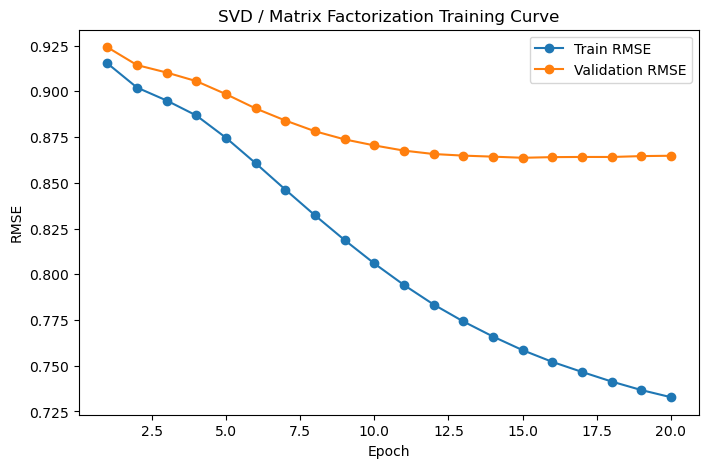

In [11]:
# Plot training curve
hist_svd = pd.DataFrame(model_svd["history"], columns=["epoch", "train_rmse", "val_rmse"])

plt.figure(figsize=(8, 5))
plt.plot(hist_svd["epoch"], hist_svd["train_rmse"], marker="o", label="Train RMSE")
plt.plot(hist_svd["epoch"], hist_svd["val_rmse"], marker="o", label="Validation RMSE")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("SVD / Matrix Factorization Training Curve")
plt.legend()
plt.show()

In [12]:
# Single prediction helper
def predict_rating_svd(model, raw_user_id, raw_movie_id):
    if raw_user_id not in user2idx or raw_movie_id not in movie2idx:
        return None

    u = user2idx[raw_user_id]
    i = movie2idx[raw_movie_id]

    pred = (
        model["global_mean"]
        + model["bu"][u]
        + model["bi"][i]
        + np.dot(model["P"][u], model["Q"][i])
    )

    pred = float(np.clip(pred, 1.0, 5.0))
    return pred

In [13]:
# Example: predict one rating
sample_user = int(train_df.iloc[0]["user_id"])
sample_movie = int(train_df.iloc[0]["movie_id"])

pred_svd = predict_rating_svd(model_svd, sample_user, sample_movie)
print("Sample user_id:", sample_user)
print("Sample movie_id:", sample_movie)
print("Predicted rating:", pred_svd)

Sample user_id: 3650
Sample movie_id: 1791
Predicted rating: 2.7829094565840315


In [14]:
# Top-N recommendation helper
def recommend_top_n_svd(model, raw_user_id, top_n=10):
    if raw_user_id not in user2idx:
        return None

    u = user2idx[raw_user_id]
    seen = model["user_seen"].get(u, set())

    scores = model["global_mean"] + model["bu"][u] + model["bi"] + model["Q"] @ model["P"][u]
    scores = np.clip(scores, 1.0, 5.0)

    candidates = []
    for i_idx in range(n_items):
        if i_idx not in seen:
            candidates.append((idx2movie[i_idx], float(scores[i_idx])))

    candidates = sorted(candidates, key=lambda x: x[1], reverse=True)[:top_n]
    return pd.DataFrame(candidates, columns=["movie_id", "predicted_rating"])

In [15]:
# Example: top recommendations
rec_svd_df = recommend_top_n_svd(model_svd, sample_user, top_n=10)
display(rec_svd_df)

,movie_id,predicted_rating
0,1213,5.000000
1,590,5.000000
2,1954,5.000000
3,3360,4.964047
4,589,4.958564
5,1302,4.893999
6,1090,4.890249
7,953,4.875903
8,2905,4.861174
9,1961,4.854919


In [16]:
# Save results summary
results_summary_svd = {
    "model": "Matrix Factorization (SVD)",
    "seed": int(SEED),
    "input_features": "user_id + movie_id only",
    "task": "explicit movie rating prediction",
    "metric": "RMSE",
    "prediction_clip": "[1,5]",
    "latent_dim": int(20),
    "learning_rate": float(0.01),
    "regularization": float(0.02),
    "epochs": int(20),
    "final_val_rmse": float(final_val_rmse_svd),
    "test_rmse": float(test_rmse_svd)
}

results_summary_svd

{'model': 'Matrix Factorization (SVD)',
 'seed': 42,
 'input_features': 'user_id + movie_id only',
 'task': 'explicit movie rating prediction',
 'metric': 'RMSE',
 'prediction_clip': '[1,5]',
 'latent_dim': 20,
 'learning_rate': 0.01,
 'regularization': 0.02,
 'epochs': 20,
 'final_val_rmse': 0.8647645505142951,
 'test_rmse': 0.8612112505508045}